# 1. Generate ChArUco Board Images

True

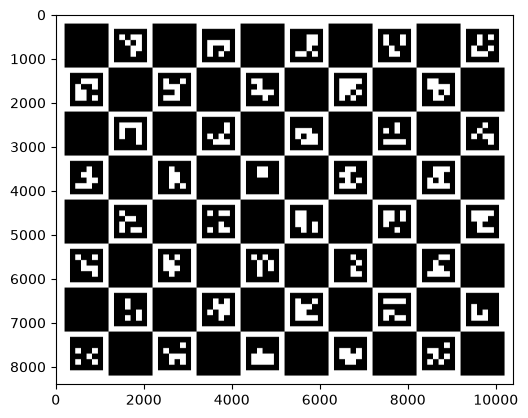

In [1]:
import cv2
from cv2 import aruco
import matplotlib.pyplot as plt

dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_250)
board = aruco.CharucoBoard(
    (10, 8),
    0.05,
    0.038,
    dictionary
)
image = board.generateImage((10400, 8400), marginSize = 200, borderBits = 1)
plt.figure()
plt.imshow(image, cmap = 'gray')
cv2.imwrite('charuco_board.png', image)

# 2. Verify old ChArUco Board Images

True

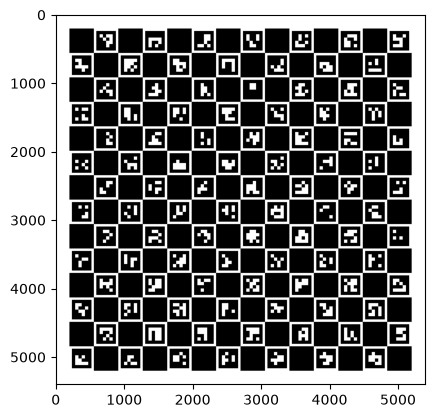

In [1]:
import cv2
from cv2 import aruco
import matplotlib.pyplot as plt

dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_250)
board = aruco.CharucoBoard(
    (14, 14),
    0.025,
    0.02,
    dictionary
)
image = board.generateImage((5400, 5400), marginSize = 200, borderBits = 1)
plt.figure()
plt.imshow(image, cmap = 'gray')
cv2.imwrite('charuco_board.png', image)

# Test detection

[ WARN:0@502.210] global aruco_board.cpp:547 CharucoBoard Marker border 0.0055 is less than 70% of ArUco pin size 0.00925. Please increase markerSeparation or decrease markerLength for stable board detection


Board config: 10x8, square=0.06650000065565109 m, marker=0.05550000071525574 m, DICT_4X4_250
Detection preprocessing: CLAHE (clipLimit=2.0, tileGridSize=(8, 8))
Detected 37 ArUco markers (79 rejected candidates)
Detected 58 / 63 ChArUco corners (92.1%)


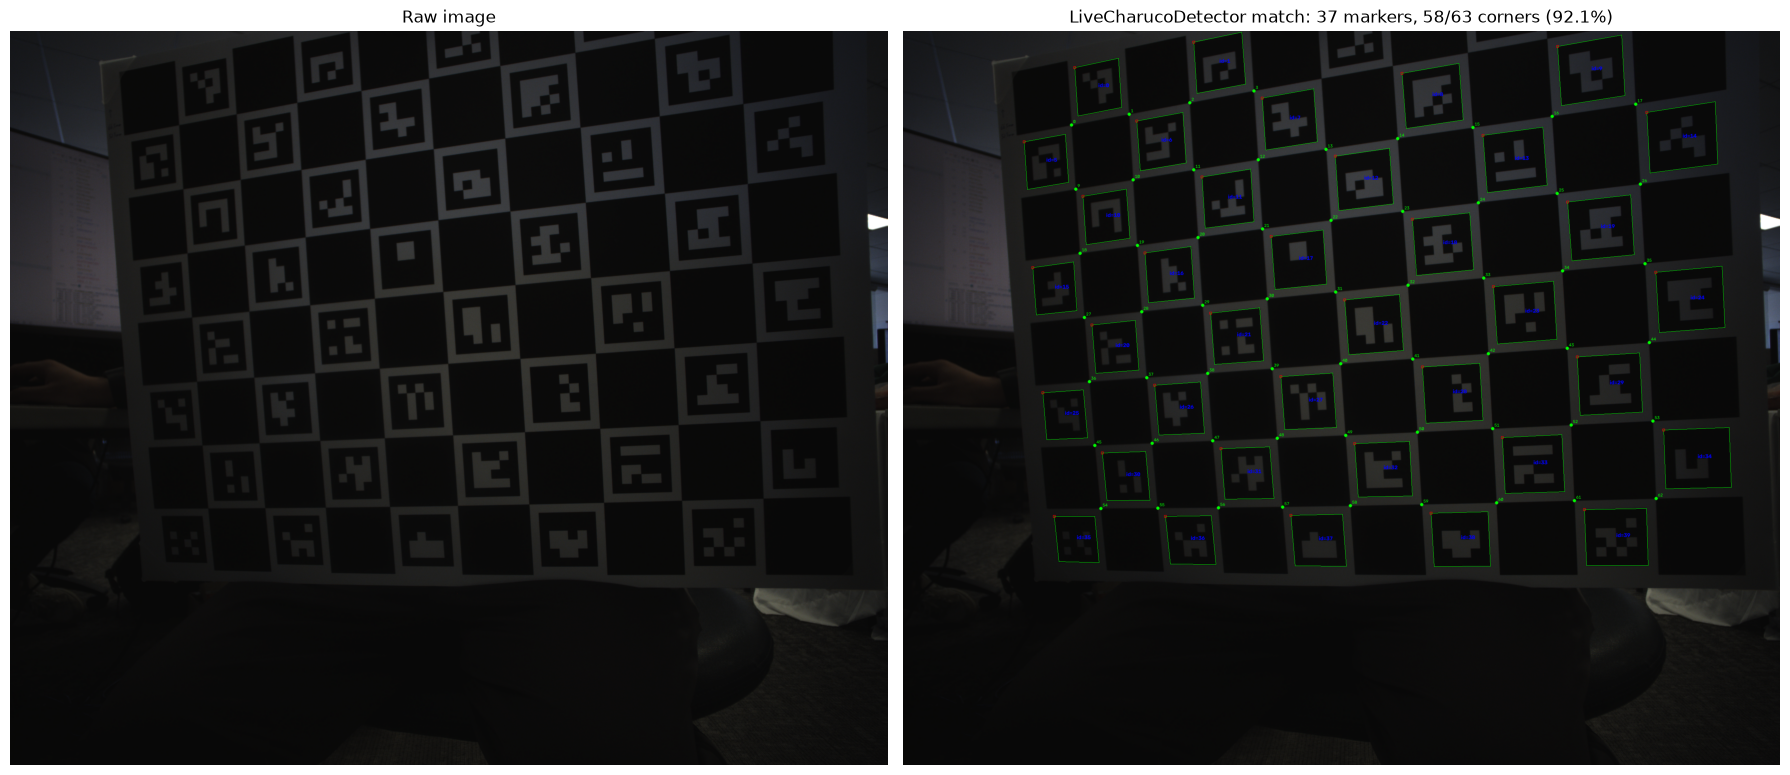

In [6]:
from pathlib import Path

import cv2
from cv2 import aruco
import matplotlib.pyplot as plt
import numpy as np

# Hard-coded from build/sentech_stereo_charuco.json (the C++ program board settings).
squares_x = 10
squares_y = 8
square_length_m = 6.6500000655651093e-02
marker_length_m = 5.5500000715255737e-02
dictionary_name = 'DICT_4X4_250'

workspace_root = Path('/home/liu4000/Desktop/FS_realsense')
dictionary_id = getattr(aruco, dictionary_name)
dictionary = aruco.getPredefinedDictionary(dictionary_id)
board = aruco.CharucoBoard(
    (squares_x, squares_y), square_length_m, marker_length_m, dictionary
)

# Change to right.png to test the right camera image.
image_path = workspace_root / 'data' / '20260811_131957' / 'left.png'
image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError(f'Unable to read image: {image_path}')

# Mirrors LiveCharucoDetector::detect(): BGR -> gray, default parameters,
# detectMarkers(), then interpolateCornersCharuco().
visualization = image.copy()
gray = cv2.cvtColor(visualization, cv2.COLOR_BGR2GRAY)
# CLAHE boosts local contrast in dark image edges without changing corner coordinates.
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
detection_gray = clahe.apply(gray)
parameters = aruco.DetectorParameters()
if hasattr(aruco, 'detectMarkers'):
    # Legacy Python binding; matches cv::aruco::detectMarkers() in the C++ app.
    marker_corners, marker_ids, rejected_candidates = aruco.detectMarkers(
        detection_gray, dictionary, parameters=parameters
    )
else:
    # Newer Python bindings expose the same detector through ArucoDetector.
    detector = aruco.ArucoDetector(dictionary, parameters)
    marker_corners, marker_ids, rejected_candidates = detector.detectMarkers(detection_gray)
marker_count = 0 if marker_ids is None else len(marker_ids)
charuco_corners = None
charuco_ids = None
if marker_count > 0:
    aruco.drawDetectedMarkers(visualization, marker_corners, marker_ids)
    if hasattr(aruco, 'interpolateCornersCharuco'):
        # Legacy Python binding; matches the C++ interpolateCornersCharuco() call.
        _, charuco_corners, charuco_ids = aruco.interpolateCornersCharuco(
            marker_corners, marker_ids, detection_gray, board
        )
    else:
        # Newer Python bindings expose the equivalent ChArUco interpolation
        # through CharucoDetector.detectBoard().
        charuco_detector = aruco.CharucoDetector(board)
        charuco_corners, charuco_ids, _, _ = charuco_detector.detectBoard(detection_gray)

# Normalize the detector output before visualization.  OpenCV 5 Python can
# reject its own CharucoDetector arrays in drawDetectedCornersCharuco(), so draw
# the same green corner overlay directly instead.
charuco_points = (
    np.empty((0, 2), dtype=np.float32)
    if charuco_corners is None
    else np.asarray(charuco_corners, dtype=np.float32).reshape(-1, 2)
)
charuco_id_values = (
    np.empty(0, dtype=np.int32)
    if charuco_ids is None
    else np.asarray(charuco_ids, dtype=np.int32).reshape(-1)
)
corner_count = min(len(charuco_points), len(charuco_id_values))
if corner_count >= 4:  # kMinimumCharucoCorners in live_charuco_detector.cpp
    for (x, y), corner_id in zip(charuco_points[:corner_count], charuco_id_values[:corner_count]):
        point = (round(float(x)), round(float(y)))
        cv2.circle(visualization, point, 4, (0, 255, 0), -1, cv2.LINE_AA)
        cv2.putText(visualization, str(corner_id), (point[0] + 5, point[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1, cv2.LINE_AA)

total_corner_count = len(board.getChessboardCorners())
corner_coverage = 100.0 * corner_count / total_corner_count
print(f'Board config: {squares_x}x{squares_y}, square={square_length_m} m, '
      f'marker={marker_length_m} m, {dictionary_name}')
print('Detection preprocessing: CLAHE (clipLimit=2.0, tileGridSize=(8, 8))')
print(f'Detected {marker_count} ArUco markers ({len(rejected_candidates)} rejected candidates)')
print(f'Detected {corner_count} / {total_corner_count} ChArUco corners ({corner_coverage:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Raw image')
axes[1].imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f'LiveCharucoDetector match: {marker_count} markers, '
    f'{corner_count}/{total_corner_count} corners ({corner_coverage:.1f}%)'
)
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()
